# OTT Streaming Content Trend Analysis - Netflix
**Role:** Content Strategy / Growth Analyst &nbsp;|&nbsp; **Audience:** Content Acquisition Team
**Dataset:** Netflix titles catalog (8,807 rows, 12 columns; titles added 2008 - 25 Sep 2021)

**Business question:** *How has the catalog changed over the years - by format, genre, audience rating and region - and what should the acquisition team greenlight next?*

**Notebook flow**
1. Setup and chart style
2. Data cleaning and feature engineering
3. EDA - 9 visualizations, each with a "so what"
4. Genre momentum table (what is gaining share)
5. SQL cross-check (Python results validated against the SQL in `sql/queries.sql`)
6. Key findings that feed the strategy memo

## 1. Setup

In [1]:
import re, sqlite3, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA, IMG = ROOT / "data", ROOT / "images"
IMG.mkdir(exist_ok=True)

# Palette: validated categorical order (blue, orange, aqua) + neutral ink tokens.
# Colour follows the entity everywhere: Movie = blue, TV Show = orange.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SURF, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
TYPE_COLOR = {"Movie": BLUE, "TV Show": ORANGE}
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#3987e5", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK2,
    "font.family": "DejaVu Sans", "font.size": 10, "legend.frameon": False,
    "lines.linewidth": 2.2, "lines.markersize": 6,
})

def save(fig, name):
    fig.savefig(IMG / name, dpi=150, bbox_inches="tight")
    plt.show()

## 2. Data cleaning and feature engineering
Raw-data issues found while profiling, and how each is handled:

| Issue | Evidence | Treatment |
|---|---|---|
| Missing `director`, `cast`, `country` | 2,634 / 825 / 831 nulls | Fill with `"Unknown"` (keeps the row; excluded from country analysis) |
| Shifted rows | 3 rows hold a runtime like `"74 min"` in `rating` and a null `duration` | Move value to `duration`, set rating to `"Not Rated"` |
| Missing `rating` | 4 nulls (+3 from above) | `"Not Rated"` |
| `date_added` is text | `"September 25, 2021"` | Parse to datetime; extract `year_added`, `month_added` (10 nulls kept as NaT) |
| `duration` is text with mixed units | `"90 min"` vs `"2 Seasons"` | Split into numeric `duration_min` (movies) and `seasons` (TV) |
| Multi-valued `listed_in`, `country` | `"Dramas, Comedies"` | Explode into long tables (`genres`, `countries`) |
| Duplicates | 1 title listed twice with different `show_id` | Drop (title + type + year + country + date match) |
| Too many rating codes (14) | TV-MA, R, TV-14, ... | Group into audience segments: Kids / Teens / Adults / Not Rated |

In [2]:
raw = pd.read_csv(DATA / "netflix_titles.csv")
print("Raw shape:", raw.shape)
print("\nNulls per column:")
print(raw.isna().sum()[raw.isna().sum() > 0].to_string())
print("\nRating values that are really durations:", raw["rating"].astype(str).str.contains("min").sum())

Raw shape: (8807, 12)

Nulls per column:
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3

Rating values that are really durations: 3


In [3]:
df = raw.copy()

# 1) whitespace
for c in df.select_dtypes(include=["object", "string"]).columns:
    df[c] = df[c].str.strip()

# 2) shifted rows: duration stored in `rating`
shifted = df["rating"].astype(str).str.contains("min", na=False)
df.loc[shifted, "duration"] = df.loc[shifted, "rating"]
df.loc[shifted, "rating"] = pd.NA

# 3) missing categoricals
for c in ["director", "cast", "country"]:
    df[c] = df[c].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")

# 4) dates
df["date_added"] = pd.to_datetime(df["date_added"], format="%B %d, %Y", errors="coerce")
df["year_added"] = df["date_added"].dt.year.astype("Int64")
df["month_added"] = df["date_added"].dt.month.astype("Int64")

# 5) duration -> numeric
num = pd.to_numeric(df["duration"].str.extract(r"(\d+)")[0], errors="coerce")
df["duration_min"] = num.where(df["type"] == "Movie")
df["seasons"] = num.where(df["type"] == "TV Show")

# 6) audience segment from rating
audience_map = {
    "TV-Y": "Kids", "TV-Y7": "Kids", "TV-Y7-FV": "Kids", "TV-G": "Kids", "G": "Kids",
    "TV-PG": "Teens", "PG": "Teens", "TV-14": "Teens", "PG-13": "Teens",
    "TV-MA": "Adults", "R": "Adults", "NC-17": "Adults",
    "NR": "Not Rated", "UR": "Not Rated", "Not Rated": "Not Rated",
}
df["audience"] = df["rating"].map(audience_map).fillna("Not Rated")

# 7) other features
df["primary_country"] = df["country"].str.split(",").str[0].str.strip()
df["primary_genre"] = df["listed_in"].str.split(",").str[0].str.strip()
df["lag_years"] = (df["year_added"] - df["release_year"]).astype("Int64")

# 8) duplicates
dup_cols = ["title", "type", "release_year", "country", "date_added"]
print("Duplicate rows dropped:", df.duplicated(dup_cols).sum())
df = df.drop_duplicates(dup_cols).reset_index(drop=True)

# 9) exploded tables
genres = (df[["show_id", "type", "release_year", "year_added", "listed_in"]]
          .assign(genre=lambda d: d["listed_in"].str.split(",")).explode("genre").drop(columns="listed_in"))
genres["genre"] = genres["genre"].str.strip()

countries = (df[["show_id", "type", "release_year", "year_added", "country"]]
             .assign(country=lambda d: d["country"].str.split(",")).explode("country"))
countries["country"] = countries["country"].str.strip()
countries = countries[countries["country"].notna() & (countries["country"] != "")]
countries_known = countries[countries["country"] != "Unknown"]

print("Clean titles:", len(df), "| genre rows:", len(genres), "| country rows:", len(countries))
print("Nulls left in modelled columns:", int(df[["type", "title", "release_year", "rating", "country"]].isna().sum().sum()))
print("Date range added:", df["date_added"].min().date(), "->", df["date_added"].max().date())
df.head(3)

Duplicate rows dropped: 1


Clean titles: 8806 | genre rows: 19320 | country rows: 10842
Nulls left in modelled columns: 0
Date range added: 2008-01-01 -> 2021-09-25


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_min,seasons,audience,primary_country,primary_genre,lag_years
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,90.0,NaN,Teens,United States,Documentaries,1
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,NaN,2.0,Adults,South Africa,International TV Shows,0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,NaN,1.0,Adults,Unknown,Crime TV Shows,0


In [4]:
# Persist the cleaned tables (same outputs as scripts/clean_data.py)
df.to_csv(DATA / "netflix_clean.csv", index=False)
genres.to_csv(DATA / "netflix_genres.csv", index=False)
countries.to_csv(DATA / "netflix_countries.csv", index=False)

# Reference years used throughout. 2021 is a PARTIAL year (data ends 25-Sep-2021).
YEARS = list(range(2016, 2022))
print("Catalog split:"); print(df["type"].value_counts().to_frame("titles").assign(pct=lambda d: (100*d.titles/d.titles.sum()).round(1)))

Catalog split:
         titles   pct
type                 
Movie      6130  69.6
TV Show    2676  30.4


## 3. Exploratory analysis
### 3.1 Catalog growth: how many titles were added each year, by format?

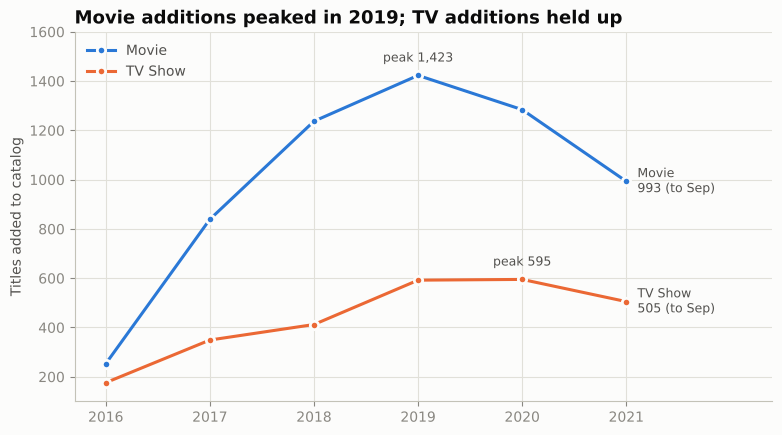

type,Movie,TV Show,total
year_added,,,
2016,253,176,429
2017,839,349,1188
2018,1237,412,1649
2019,1423,592,2015
2020,1284,595,1879
2021,993,505,1498


In [5]:
add = (df[df["year_added"].isin(YEARS)].groupby(["year_added", "type"]).size().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(9, 4.8))
for t in ["Movie", "TV Show"]:
    ax.plot(add.index, add[t], marker="o", color=TYPE_COLOR[t], label=t,
            markeredgecolor=SURF, markeredgewidth=2)
    ax.annotate(f"{t}\n{add[t].iloc[-1]:,} (to Sep)", (add.index[-1], add[t].iloc[-1]),
                xytext=(8, 0), textcoords="offset points", va="center", color=INK2, fontsize=9)
    pk = add[t].idxmax()
    ax.annotate(f"peak {add[t].max():,}", (pk, add[t].max()), xytext=(0, 10),
                textcoords="offset points", ha="center", color=INK2, fontsize=9)
ax.set_xlim(2015.7, 2022.4)
ax.set_xticks(YEARS)
ax.set_title("Movie additions peaked in 2019; TV additions held up")
ax.set_ylabel("Titles added to catalog")
ax.set_ylim(100, 1600)
ax.legend(loc="upper left")
save(fig, "01_additions_by_year.png")
add.assign(total=add.sum(axis=1))

**So what:** The library grew ~5x from 2016 to 2019, then movie additions started shrinking while series additions stayed flat-to-up. Growth is no longer coming from movies.

### 3.2 Format mix: is the pipeline shifting toward series?

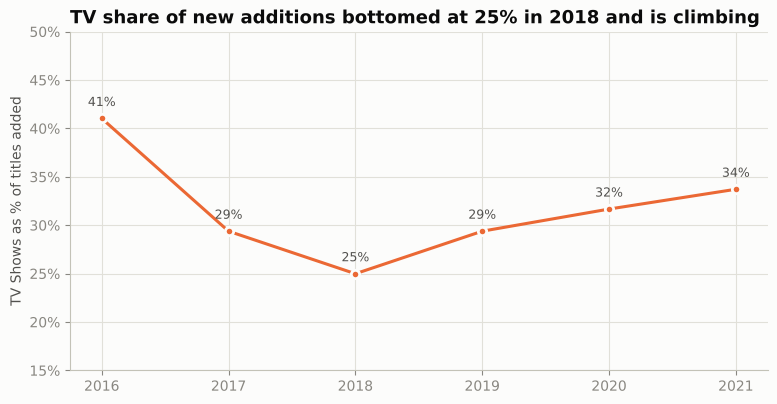

year_added
2016    41.0
2017    29.4
2018    25.0
2019    29.4
2020    31.7
2021    33.7
Name: type, dtype: float64

In [6]:
tv_share = (df[df["year_added"].isin(YEARS)].groupby("year_added")["type"]
            .apply(lambda s: 100 * (s == "TV Show").mean()))

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(tv_share.index, tv_share.values, marker="o", color=ORANGE, markeredgecolor=SURF, markeredgewidth=2)
for x, y in tv_share.items():
    ax.annotate(f"{y:.0f}%", (x, y), xytext=(0, 9), textcoords="offset points", ha="center", color=INK2, fontsize=9)
ax.set_xticks(YEARS)
ax.set_ylim(15, 50)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title("TV share of new additions bottomed at 25% in 2018 and is climbing")
ax.set_ylabel("TV Shows as % of titles added")
save(fig, "02_tv_share_by_year.png")
tv_share.round(1)

**So what:** After a 2018 low (25%), series are a growing slice of what is added - about one in three new titles by 2021. 2016's 41% sits on a tiny base (429 titles) and is not a trend.

### 3.3 Genre popularity: what dominates the catalog?

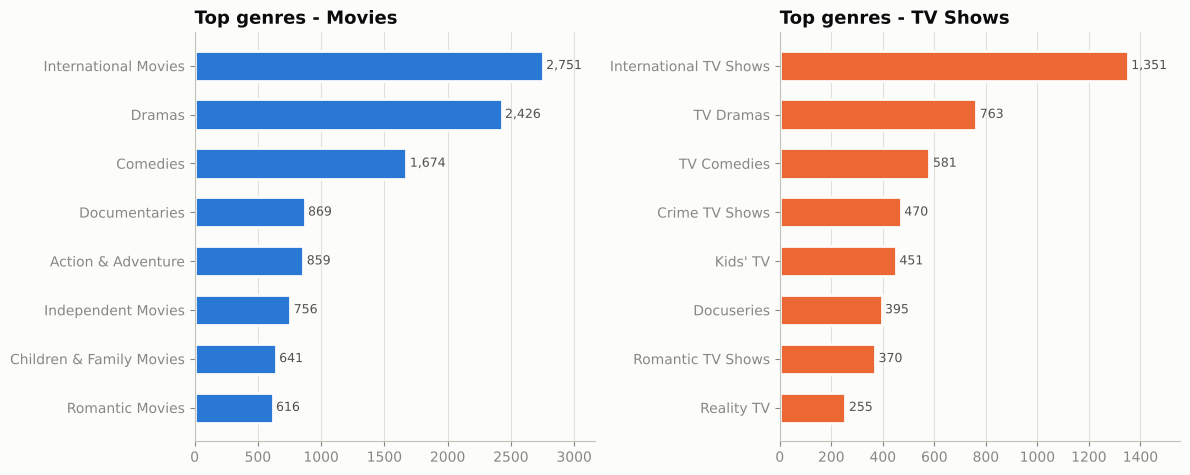

In [7]:
g_type = genres.groupby(["type", "genre"]).size().rename("titles").reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False)
for ax, t in zip(axes, ["Movie", "TV Show"]):
    top = g_type[g_type["type"] == t].nlargest(8, "titles").sort_values("titles")
    ax.barh(top["genre"], top["titles"], color=TYPE_COLOR[t], height=0.62, edgecolor=SURF, linewidth=2)
    for y, v in enumerate(top["titles"]):
        ax.text(v + top["titles"].max() * 0.01, y, f"{v:,}", va="center", color=INK2, fontsize=9)
    ax.set_title(f"Top genres - {t}s")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, top["titles"].max() * 1.15)
fig.suptitle("")
fig.tight_layout()
save(fig, "03_top_genres.png")

**So what:** *International* is the single biggest tag for both formats - the catalog is already global. Dramas and Comedies anchor movies; Dramas, Comedies and Crime anchor series.

### 3.4 Genre mix over time (share of each year's additions)

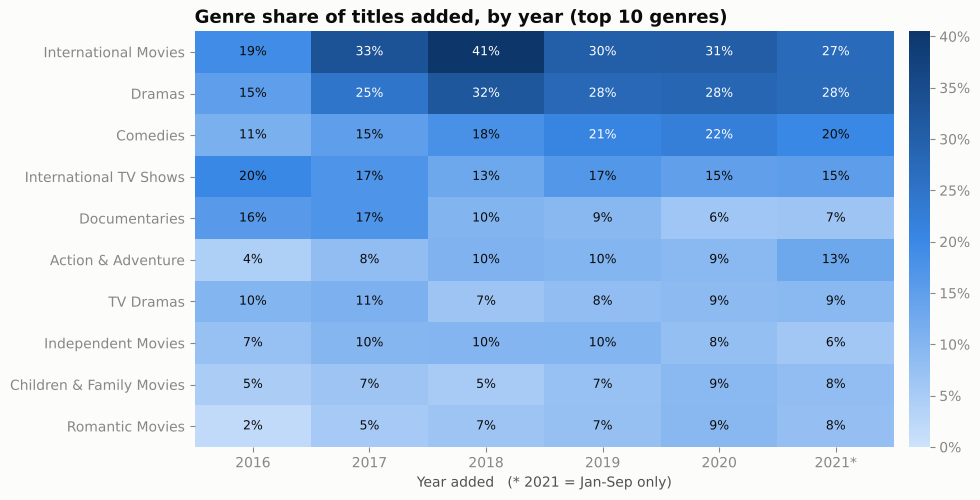

In [8]:
top_genres = genres["genre"].value_counts().head(10).index.tolist()
gy = genres[genres["year_added"].isin(YEARS)]
tot_by_year = df[df["year_added"].isin(YEARS)].groupby("year_added").size()
heat = (gy[gy["genre"].isin(top_genres)].groupby(["genre", "year_added"]).size().unstack(fill_value=0)
        .div(tot_by_year, axis=1) * 100).loc[top_genres]

fig, ax = plt.subplots(figsize=(9.5, 5.4))
im = ax.imshow(heat.values, cmap=SEQ, aspect="auto", vmin=0, vmax=heat.values.max())
ax.set_xticks(range(len(heat.columns)), [str(c) + ("*" if c == 2021 else "") for c in heat.columns])
ax.set_yticks(range(len(heat.index)), heat.index)
ax.grid(False)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=9,
                color="white" if v > heat.values.max() * 0.5 else INK)
ax.set_title("Genre share of titles added, by year (top 10 genres)")
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
cb.outline.set_visible(False)
ax.set_xlabel("Year added   (* 2021 = Jan-Sep only)")
for s in ax.spines.values():
    s.set_visible(False)
save(fig, "04_genre_heatmap.png")

**So what:** Share is a better lens than counts because the catalog grew so fast. Comedies and the family/romance tags have gained share while Dramas stay flat at the top.

### 3.5 Content ratings: who is the catalog for?

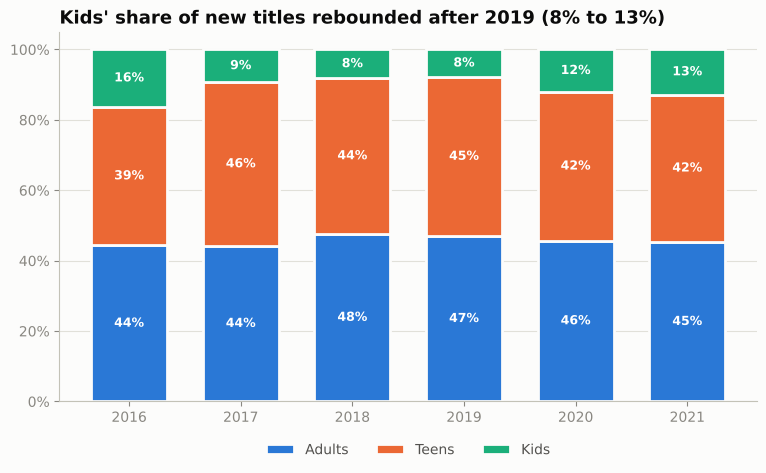

Full-catalog rating distribution (top 8):
        titles   pct
rating              
TV-MA     3206  36.4
TV-14     2160  24.5
TV-PG      863   9.8
R          799   9.1
PG-13      490   5.6
TV-Y7      334   3.8
TV-Y       307   3.5
PG         287   3.3


In [9]:
aud = (df[df["year_added"].isin(YEARS) & df["audience"].isin(["Kids", "Teens", "Adults"])]
       .groupby(["year_added", "audience"]).size().unstack(fill_value=0))
aud_pct = aud.div(aud.sum(axis=1), axis=0) * 100
AUD_COLOR = {"Adults": BLUE, "Teens": ORANGE, "Kids": AQUA}

fig, ax = plt.subplots(figsize=(9, 4.8))
bottom = np.zeros(len(aud_pct))
for a in ["Adults", "Teens", "Kids"]:
    ax.bar(aud_pct.index, aud_pct[a], bottom=bottom, color=AUD_COLOR[a], label=a,
           width=0.68, edgecolor=SURF, linewidth=2)
    for x, b, v in zip(aud_pct.index, bottom, aud_pct[a]):
        ax.text(x, b + v / 2, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
    bottom += aud_pct[a].values
ax.set_xticks(YEARS)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(axis="x", visible=False)
ax.set_title("Kids' share of new titles rebounded after 2019 (8% to 13%)")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.08))
save(fig, "05_audience_mix.png")
print("Full-catalog rating distribution (top 8):")
print(df["rating"].value_counts().head(8).to_frame("titles").assign(pct=lambda d: (100*d.titles/len(df)).round(1)))

**So what:** The catalog is adult/teen dominated (TV-MA and TV-14 are ~61% of all titles), but the kids/family segment has been growing again since 2019 - a different audience and a household-retention lever.

### 3.6 Regional mix: where does the content come from?

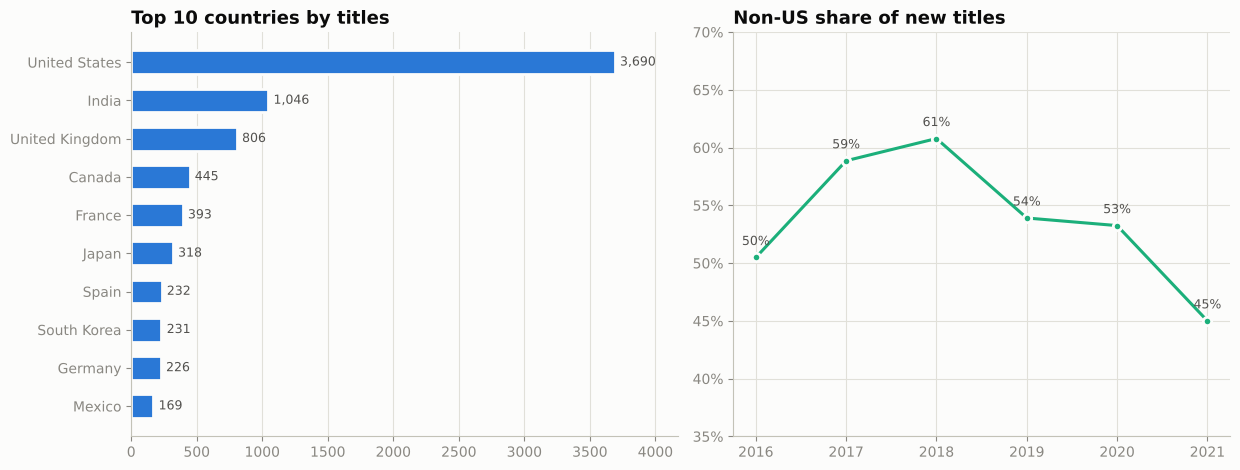

Non-US share (%), titles with known country:
year_added
2016    50.5
2017    58.9
2018    60.8
2019    53.9
2020    53.2
2021    45.0


In [10]:
top_c = countries_known["country"].value_counts().head(10).sort_values()
us_ids = set(countries_known.loc[countries_known["country"] == "United States", "show_id"])
known_ids = countries_known.drop_duplicates("show_id")[["show_id", "year_added"]]
known_ids = known_ids.assign(non_us=~known_ids["show_id"].isin(us_ids))
non_us = known_ids[known_ids["year_added"].isin(YEARS)].groupby("year_added")["non_us"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw={"width_ratios": [1.1, 1]})
ax = axes[0]
ax.barh(top_c.index, top_c.values, color=BLUE, height=0.62, edgecolor=SURF, linewidth=2)
for y, v in enumerate(top_c.values):
    ax.text(v + 40, y, f"{v:,}", va="center", color=INK2, fontsize=9)
ax.set_xlim(0, top_c.max() * 1.13)
ax.grid(axis="y", visible=False)
ax.set_title("Top 10 countries by titles")

ax = axes[1]
ax.plot(non_us.index, non_us.values, marker="o", color=AQUA, markeredgecolor=SURF, markeredgewidth=2)
for x, y in non_us.items():
    ax.annotate(f"{y:.0f}%", (x, y), xytext=(0, 9), textcoords="offset points", ha="center", color=INK2, fontsize=9)
ax.set_ylim(35, 70)
ax.set_xticks(YEARS)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title("Non-US share of new titles")
fig.tight_layout()
save(fig, "06_country_mix.png")
print("Non-US share (%), titles with known country:"); print(non_us.round(1).to_string())

**So what:** The US accounts for ~46% of titles with a known country, and India is a clear #2 (~13%). The non-US share of *new* additions peaked around 2018 (61%) and has slipped to 45% in 2021 - international is no longer the growth engine it was.

### 3.7 Country momentum: which markets are growing, which have cooled?

year_added,2016,2017,2018,2019,2020,2021
country,,,,,,
United States,203,462,600,856,828,627
India,13,162,349,218,199,105
United Kingdom,54,134,147,191,146,120
Japan,29,37,44,74,79,53
South Korea,11,43,33,59,56,29
Spain,17,42,43,53,43,33
France,29,53,64,79,97,60
Canada,30,71,81,84,110,59


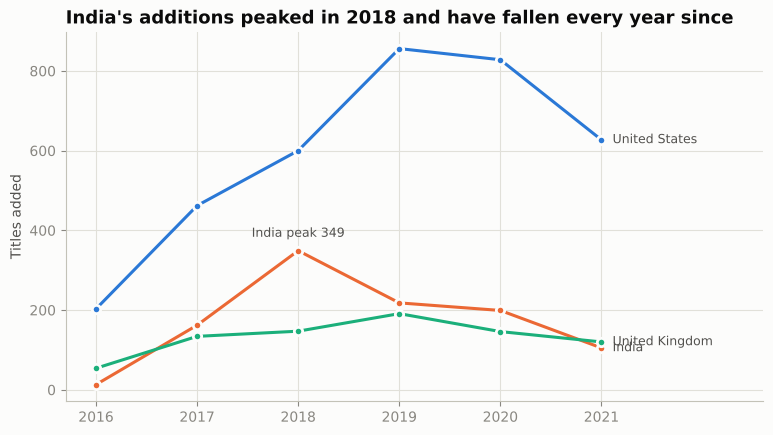

In [11]:
focus = ["United States", "India", "United Kingdom", "Japan", "South Korea", "Spain", "France", "Canada"]
cy = (countries_known[countries_known["country"].isin(focus) & countries_known["year_added"].isin(YEARS)]
      .groupby(["country", "year_added"]).size().unstack(fill_value=0).loc[focus])
display(cy)

fig, ax = plt.subplots(figsize=(9, 4.8))
for c, col in [("United States", BLUE), ("India", ORANGE), ("United Kingdom", AQUA)]:
    ax.plot(cy.columns, cy.loc[c], marker="o", color=col, markeredgecolor=SURF, markeredgewidth=2)
    ax.annotate(c, (cy.columns[-1], cy.loc[c].iloc[-1]), xytext=(8, 0), textcoords="offset points", va="center", color=INK2, fontsize=9)
ax.annotate(f"India peak {cy.loc['India'].max()}", (cy.loc["India"].idxmax(), cy.loc["India"].max()),
            xytext=(0, 10), textcoords="offset points", ha="center", color=INK2, fontsize=9)
ax.set_xlim(2015.7, 2022.6)
ax.set_xticks(YEARS)
ax.set_title("India's additions peaked in 2018 and have fallen every year since")
ax.set_ylabel("Titles added")
save(fig, "07_country_momentum.png")

**So what:** India's wave (162 titles in 2017, 349 in 2018) was 43% lower by full-year 2020 (199) and 2021 is running lower again (105 through September), while Japan and South Korea hold a steady niche (see genre profile below). That is the opening for a deliberate, curated regional push rather than bulk licensing.

In [12]:
# What does each focus market make? Top 3 genres per country (join of the two exploded tables)
cg = (countries_known[countries_known["country"].isin(["India", "South Korea", "Japan", "United Kingdom", "Spain"])]
      [["show_id", "country"]].merge(genres[["show_id", "genre"]], on="show_id")
      .groupby(["country", "genre"]).size().rename("titles").reset_index())
cg["rank"] = cg.groupby("country")["titles"].rank(method="first", ascending=False)
cg[cg["rank"] <= 3].sort_values(["country", "rank"]).drop(columns="rank")

,country,genre,titles
13,India,International Movies,864
9,India,Dramas,662
4,India,Comedies,323
50,Japan,International TV Shows,151
37,Japan,Anime Series,143
49,Japan,International Movies,72
80,South Korea,International TV Shows,152
82,South Korea,Korean TV Shows,132
88,South Korea,Romantic TV Shows,77
112,Spain,International Movies,140


### 3.8 Duration: are movies getting shorter? Do shows get renewed?

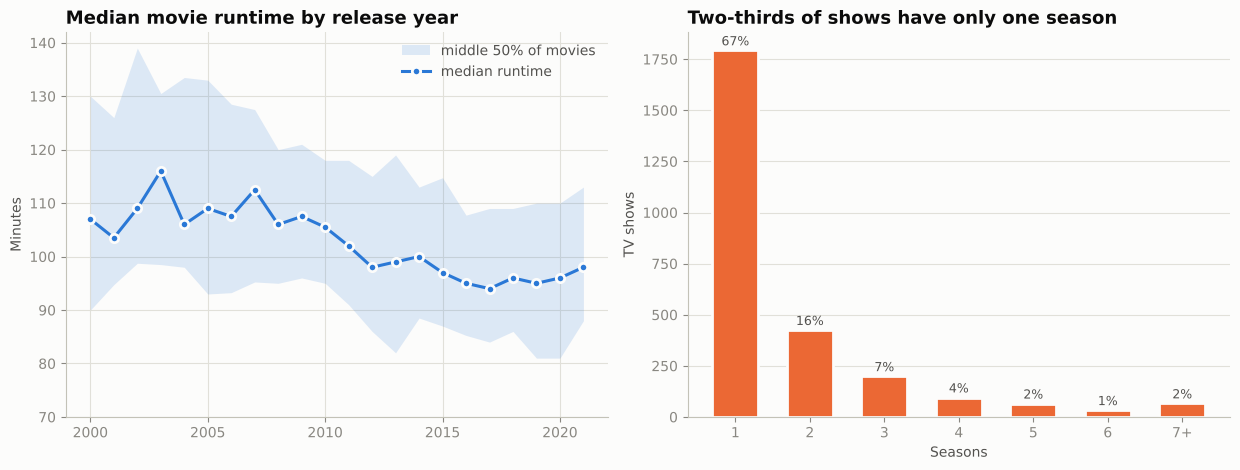

1-season share of TV titles: 67.0%
Median movie runtime (release 2000-04 vs 2017-21): 108 vs 96 min


In [13]:
mv = df[(df["type"] == "Movie") & df["duration_min"].notna() & (df["release_year"] >= 2000)]
q = mv.groupby("release_year")["duration_min"].quantile([0.25, 0.5, 0.75]).unstack()
ts = df[df["type"] == "TV Show"]["seasons"].value_counts().sort_index()
ts_top = ts[ts.index <= 6]
other = ts[ts.index > 6].sum()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
ax = axes[0]
ax.fill_between(q.index, q[0.25], q[0.75], color=BLUE, alpha=0.15, linewidth=0, label="middle 50% of movies")
ax.plot(q.index, q[0.5], color=BLUE, marker="o", markeredgecolor=SURF, markeredgewidth=2, label="median runtime")
ax.set_ylim(70, 142)
ax.set_title("Median movie runtime by release year")
ax.set_ylabel("Minutes")
ax.legend(loc="upper right")

ax = axes[1]
labels = [f"{int(i)}" for i in ts_top.index] + ["7+"]
vals = list(ts_top.values) + [other]
ax.bar(labels, vals, color=ORANGE, width=0.62, edgecolor=SURF, linewidth=2)
for x, v in enumerate(vals):
    ax.text(x, v + 25, f"{100*v/ts.sum():.0f}%", ha="center", color=INK2, fontsize=9)
ax.grid(axis="x", visible=False)
ax.set_xlabel("Seasons")
ax.set_ylabel("TV shows")
ax.set_title("Two-thirds of shows have only one season")
fig.tight_layout()
save(fig, "08_duration.png")
print("1-season share of TV titles: %.1f%%" % (100 * ts.loc[1] / ts.sum()))
print("Median movie runtime (release 2000-04 vs 2017-21): %.0f vs %.0f min" % (
    mv[mv.release_year.between(2000, 2004)].duration_min.median(), mv[mv.release_year.between(2017, 2021)].duration_min.median()))

**So what:** Median movie length has fallen from about 108 minutes (2000-04 releases) to about 96 minutes (2017-21 releases). On the TV side, 67% of titles have a single season: either limited series by design or shows that never earned a renewal. Season-1 hit rate matters far more than back-catalog depth.

### 3.9 Freshness: how old is the content when it arrives?

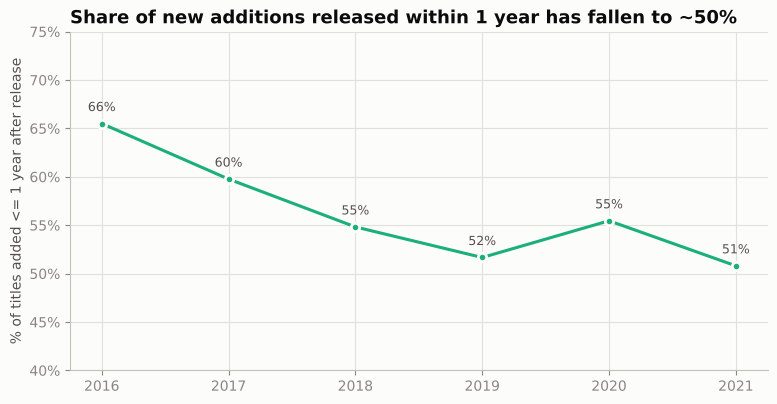

,avg_lag,within_1yr
year_added,,
2016,2.9,65.5
2017,3.9,59.8
2018,4.1,54.8
2019,5.3,51.7
2020,4.7,55.5
2021,5.8,50.8


In [14]:
fresh = (df[df["year_added"].isin(YEARS) & df["lag_years"].notna()].groupby("year_added")
         .agg(avg_lag=("lag_years", "mean"),
              within_1yr=("lag_years", lambda s: 100 * (s <= 1).mean())))
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(fresh.index, fresh["within_1yr"], marker="o", color=AQUA, markeredgecolor=SURF, markeredgewidth=2)
for x, y in fresh["within_1yr"].items():
    ax.annotate(f"{y:.0f}%", (x, y), xytext=(0, 9), textcoords="offset points", ha="center", color=INK2, fontsize=9)
ax.set_xticks(YEARS)
ax.set_ylim(40, 75)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title("Share of new additions released within 1 year has fallen to ~50%")
ax.set_ylabel("% of titles added <= 1 year after release")
save(fig, "09_freshness.png")
fresh.round(1)

**So what:** The share of 'fresh' content (added within a year of release) slid from 66% in 2016 to ~51% in 2021, and average content age at arrival rose from 2.9 to 5.8 years. Newly added titles lean more on older / licensed material - a freshness gap that originals and day-and-date deals can fill.

## 4. Genre momentum - what is gaining share of new additions?

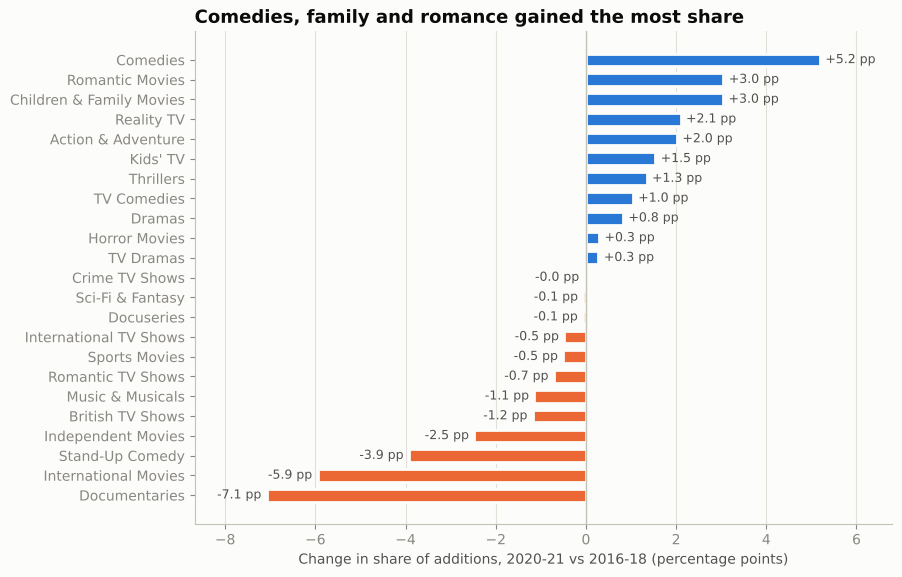

,early_share_2016_18,late_share_2020_21,change_pp,titles_in_window
genre,,,,
Comedies,15.98,21.17,5.19,1237
Romantic Movies,5.45,8.50,3.05,465
Children & Family Movies,5.60,8.65,3.04,475
Reality TV,1.87,3.97,2.10,195
Action & Adventure,8.82,10.84,2.02,654
Kids' TV,4.56,6.10,1.54,355
Thrillers,5.91,7.25,1.35,438
TV Comedies,6.18,7.23,1.04,446
Dramas,27.22,28.04,0.82,1836


In [15]:
early = df[df["year_added"].isin([2016, 2017, 2018])]
late = df[df["year_added"].isin([2020, 2021])]
g_early = genres[genres["show_id"].isin(early["show_id"])]["genre"].value_counts() / len(early) * 100
g_late = genres[genres["show_id"].isin(late["show_id"])]["genre"].value_counts() / len(late) * 100
mom = pd.concat([g_early.rename("early_share_2016_18"), g_late.rename("late_share_2020_21")], axis=1).fillna(0)
mom["change_pp"] = mom["late_share_2020_21"] - mom["early_share_2016_18"]
mom["titles_in_window"] = (genres[genres["show_id"].isin(pd.concat([early, late])["show_id"])]["genre"].value_counts())
mom = mom[mom["titles_in_window"] >= 150].sort_values("change_pp", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6.4))
m = mom.sort_values("change_pp")
cols = [BLUE if v >= 0 else ORANGE for v in m["change_pp"]]
ax.barh(m.index, m["change_pp"], color=cols, height=0.64, edgecolor=SURF, linewidth=2)
for y, v in enumerate(m["change_pp"]):
    ax.text(v + (0.12 if v >= 0 else -0.12), y, f"{v:+.1f} pp", va="center", ha="left" if v >= 0 else "right", color=INK2, fontsize=9)
ax.axvline(0, color=AXIS, linewidth=1)
ax.set_xlim(m["change_pp"].min() - 1.6, m["change_pp"].max() + 1.6)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Change in share of additions, 2020-21 vs 2016-18 (percentage points)")
ax.set_title("Comedies, family and romance gained the most share")
save(fig, "10_genre_momentum.png")
mom.round(2)

**Reading the chart:** blue = gaining share, orange = losing share. Comedies (+5.2 pp), Children & Family Movies (+3.0 pp), Romantic Movies (+3.0 pp) and Reality TV (+2.1 pp) are the clear gainers. Documentaries (-7.1 pp), International Movies (-5.9 pp) and Stand-Up Comedy (-3.9 pp) lost the most share.

## 5. SQL cross-check
The core aggregations are written as SQL in `sql/queries.sql` and run here against a SQLite copy of the cleaned tables (`data/netflix.db`, built by `scripts/clean_data.py`). Two of them are asserted against the pandas results above to prove the two paths agree.

In [16]:
import sqlite3
con = sqlite3.connect(DATA / "netflix.db")
blocks = re.split(r"-- name: (\w+)\n", (ROOT / "sql" / "queries.sql").read_text())[1:]
Q = dict(zip(blocks[::2], blocks[1::2]))
print("Queries loaded:", len(Q)); print(list(Q))

def run(name):
    return pd.read_sql_query(Q[name], con)

# Check 1: additions per year by type
sql1 = run("q02_additions_per_year_by_type").set_index("year_added").loc[YEARS]
assert (sql1["movies_added"].values == add["Movie"].values).all()
assert (sql1["tv_added"].values == add["TV Show"].values).all()

# Check 2: TV share of additions
sql2 = run("q03_tv_share_of_additions").set_index("year_added")["tv_share_pct"]
assert np.allclose(sql2.values, tv_share.round(1).values, atol=0.11)
print("SQL and pandas agree on additions-by-type and TV share.")
run("q05_genre_momentum").head(8)

Queries loaded: 14
['q01_catalog_size_by_type', 'q02_additions_per_year_by_type', 'q03_tv_share_of_additions', 'q04_top_genres_by_type', 'q05_genre_momentum', 'q06_audience_mix_by_year', 'q07_rating_detail', 'q08_top_countries', 'q09_non_us_share_by_year', 'q10_country_growth', 'q11_top_genres_by_country', 'q12_movie_runtime_trend', 'q13_tv_season_distribution', 'q14_content_freshness']
SQL and pandas agree on additions-by-type and TV share.


,genre,titles_in_window,early_share_pct,late_share_pct,share_change_pp
0,Comedies,1237,15.98,21.17,5.19
1,Children & Family Movies,475,5.60,8.65,3.05
2,Romantic Movies,465,5.45,8.50,3.05
3,Reality TV,195,1.87,3.97,2.10
4,Action & Adventure,654,8.82,10.84,2.02
5,Kids' TV,355,4.56,6.10,1.54
6,Thrillers,438,5.91,7.25,1.34
7,TV Comedies,446,6.18,7.23,1.05


In [17]:
run('q10_country_growth')

,country,y2016,y2017,y2018,y2019,y2020,y2021
0,United States,203,462,600,856,828,627
1,India,13,162,349,218,199,105
2,United Kingdom,54,134,147,191,146,120
3,Canada,30,71,81,84,110,59
4,France,29,53,64,79,97,60
5,Japan,29,37,44,74,79,53
6,South Korea,11,43,33,59,56,29
7,Spain,17,42,43,53,43,33


In [18]:
run('q14_content_freshness')

,year_added,avg_lag_years,pct_added_within_1yr_of_release
0,2016,2.9,65.5
1,2017,3.9,59.8
2,2018,4.1,54.8
3,2019,5.3,51.7
4,2020,4.7,55.5
5,2021,5.8,50.8


## 6. Key findings that feed the strategy memo

In [19]:
f = {}
f["tv_share_2018"], f["tv_share_2021"] = tv_share[2018], tv_share[2021]
f["movie_peak_year"] = add["Movie"].idxmax(); f["movie_peak"] = int(add["Movie"].max())
f["one_season_pct"] = 100 * ts.loc[1] / ts.sum()
f["india_peak_year"], f["india_peak"], f["india_2021"] = cy.loc["India"].idxmax(), cy.loc["India"].max(), cy.loc["India", 2021]
f["non_us_peak"], f["non_us_2021"] = non_us.max(), non_us[2021]
f["kids_2019"], f["kids_2021"] = aud_pct.loc[2019, "Kids"], aud_pct.loc[2021, "Kids"]
f["fresh_2016"], f["fresh_2021"] = fresh.loc[2016, "within_1yr"], fresh.loc[2021, "within_1yr"]
f["lag_2016"], f["lag_2021"] = fresh.loc[2016, "avg_lag"], fresh.loc[2021, "avg_lag"]
f["top_gainers"] = mom.head(4)["change_pp"].round(1).to_dict()
f["top_losers"] = mom.tail(3)["change_pp"].round(1).to_dict()
for k, v in f.items():
    print(f"{k:16s}", round(v, 1) if isinstance(v, (float, np.floating)) else v)

tv_share_2018    25.0
tv_share_2021    33.7
movie_peak_year  2019
movie_peak       1423
one_season_pct   67.0
india_peak_year  2018
india_peak       349
india_2021       105
non_us_peak      60.8
non_us_2021      45.0
kids_2019        7.8
kids_2021        12.8
fresh_2016       65.5
fresh_2021       50.8
lag_2016         2.9
lag_2021         5.8
top_gainers      {'Comedies': 5.2, 'Romantic Movies': 3.0, 'Children & Family Movies': 3.0, 'Reality TV': 2.1}
top_losers       {'Stand-Up Comedy': -3.9, 'International Movies': -5.9, 'Documentaries': -7.1}


### Recommendations (detail in `reports/content_strategy_memo.md`)
1. **Shift budget from movie volume to series** - TV share of additions is rebounding off a 2018 low and two-thirds of series stop at one season, so *season-1 hit rate* is the metric to optimise.
2. **Make comedy and family/romance the volume genres** - they gained the most share and cover the broadest households (including the growing Kids segment).
3. **Replace bulk international licensing with a curated regional slate** - India's volume is 43% below its 2018 peak (full-year 2020) and lower again in 2021, and the non-US share of new titles is down from 61% to 45%; pick fewer, higher-impact titles from India, Korea and Japan.

**Caveats:** this is a *catalog* dataset - it shows what exists, not what was watched. There is no viewership, cost or subscriber data, so every recommendation is about supply mix and should be validated against engagement before budgets are committed. 2021 covers January-September only.